In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score, recall_score, f1_score, make_scorer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from scipy import stats
from sklearn.feature_selection import f_classif
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_score 
from pathlib import Path

In [ ]:
dataset_path = input("Enter the path to motor_data_complete.csv: ")
df = pd.read_csv(dataset_path)
df.head() #shows the first set of observations of the dataframe  

,Serial No,Torque (Nm),Ia (A),Ib (A),Ic (A),Irms (A),Speed (RPM),Vibration_X(g),Vibration_Y(g),Vibration_Z(g),...,Motor Temperature(℃),Time (s),State,AnomalyType,Vib_rms,TempRise,Vib_norm,Inorm,Tnorm,HI
0,1,1,0.000000,0.000000,0.000000,0.000000,0.000000,-0.277816,-0.138365,0.033716,...,26.850000,0.00,Healthy,NoFault,0.312191,1.850000,0.124262,1.000000,0.055276,0.707452
1,2,1,-2.829135,-3.787047,6.616182,4.694664,1585.842961,58.907280,41.144795,23.563548,...,26.864970,0.02,Healthy,NoFault,75.618798,1.864970,5.000000,1.436665,0.047631,0.284516
2,3,1,-0.755245,-2.213898,2.969143,2.182319,1983.053979,39.650019,27.710010,15.797346,...,26.867931,0.04,Healthy,NoFault,50.887374,1.867931,5.000000,0.132686,0.046119,0.327014
3,4,1,0.289621,-1.536759,1.247138,1.154825,1677.302504,18.653165,13.160673,7.512704,...,26.868751,0.06,Healthy,NoFault,24.032989,1.868751,5.000000,0.400613,0.045700,0.317295
4,5,1,-0.868770,-1.559140,2.427910,1.739773,1609.937242,32.732536,22.882028,13.097908,...,26.869111,0.08,Healthy,NoFault,42.030481,1.869111,5.000000,0.097008,0.045516,0.328371


In [62]:
df.info(verbose = False) #gives brief information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480000 entries, 0 to 479999
Columns: 21 entries, Serial No to HI
dtypes: float64(16), int64(3), object(2)
memory usage: 76.9+ MB


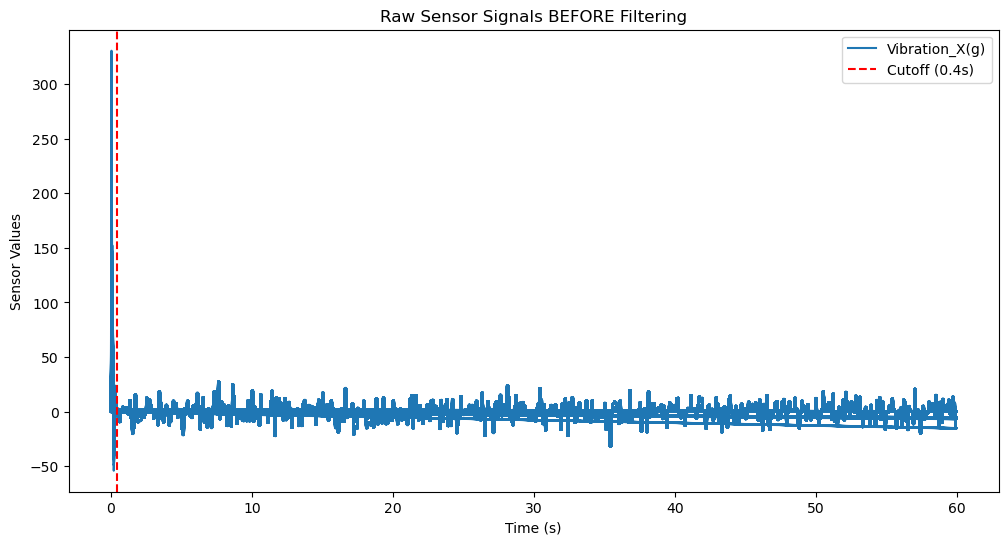

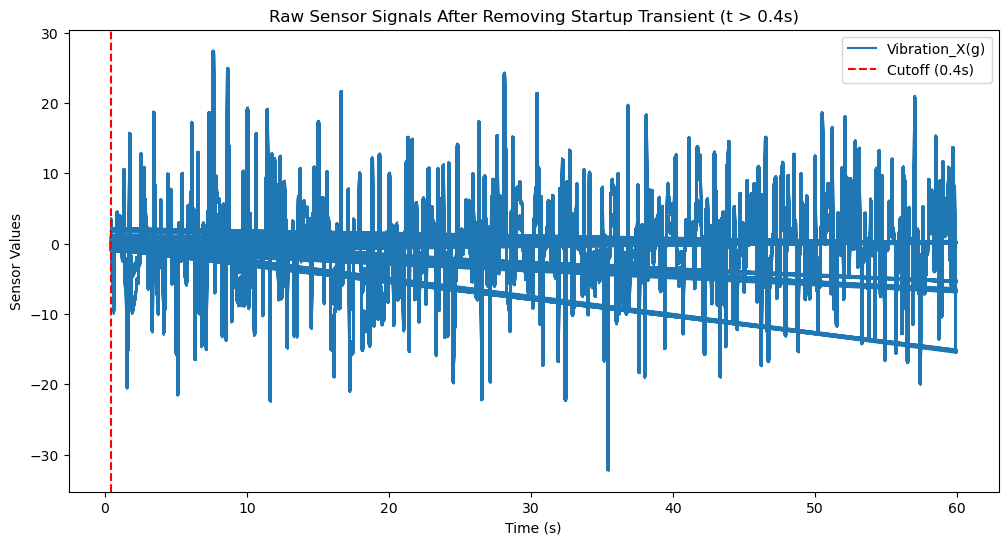

In [63]:
base_features = ["Vibration_X(g)"]

plt.figure(figsize=(12,6))

for f in base_features:
    plt.plot(df["Time (s)"], df[f], label=f)

plt.axvline(0.4, color='red', linestyle='--', label="Cutoff (0.4s)")

plt.title("Raw Sensor Signals BEFORE Filtering")
plt.xlabel("Time (s)")
plt.ylabel("Sensor Values")
plt.legend()
plt.show()

df = df[df['Time (s)'] > 0.4] #remove rows where simulation time is less than 0.4 seconds
df = df.reset_index(drop = True) #reset index after dropping rows

plt.figure(figsize=(12,6))

for f in base_features:
    plt.plot(df["Time (s)"], df[f], label=f)

plt.axvline(0.4, color='red', linestyle='--', label="Cutoff (0.4s)")

plt.title("Raw Sensor Signals After Removing Startup Transient (t > 0.4s)")
plt.xlabel("Time (s)")
plt.ylabel("Sensor Values")
plt.legend()
plt.show()

In [64]:
drop_columns = ['Serial No', 'Time (s)', 'Ambient Temperature (℃)'] #creates a list of columns not useful for prediction
df = df.drop(columns = drop_columns) #drops the columns included in the list fron the dataframe
# handling missing values and coverting columns
df['AnomalyType'] = df['AnomalyType'].fillna('NoFault') #replaces empty anomaly labels with 'NoFault'

In [29]:
# Motor-agnostic normalization
# Baseline = median of healthy rows for each signal.
# Median is used (not mean) because it is robust to any residual fault spikesthat may have leaked into the healthy subset.
healthy_rows = df[df['State'] == 'Healthy']

irms_base = healthy_rows['Irms (A)'].median()
vib_base  = healthy_rows['Vib_rms'].median()
temp_base = healthy_rows['TempRise'].median()

# Save baselines so the Pi can use them as the initial seed
training_baselines = {'Irms': irms_base, 'Vib': vib_base, 'Temp': temp_base}
print("Training baselines:", training_baselines)

# Ratio features — dimensionless, motor-size independent
df['Irms_ratio']   = df['Irms (A)'] / irms_base
df['Vib_ratio']    = df['Vib_rms']  / vib_base
df['Temp_ratio']   = df['TempRise'] / temp_base

Training baselines: {'Irms': 3.2163951885, 'Vib': 0.1608382195, 'Temp': 2.1520529450000003}


In [41]:
features = ['Irms_ratio', 'Vib_ratio', 'Temp_ratio']

X_state   = df[features].copy()
df_anomaly = df[df['AnomalyType'] != 'NoFault'].copy()
X_anomaly  = df_anomaly[features].copy()
X_hi       = df[features].copy()

y_state   = df['State']
y_anomaly = df_anomaly['AnomalyType']
y_hi      = df['HI']

In [ ]:
state_encoder   = LabelEncoder()
anomaly_encoder = LabelEncoder()

y_state_encoded   = state_encoder.fit_transform(y_state)
y_anomaly_encoded = anomaly_encoder.fit_transform(y_anomaly)

preprocessor_state   = ColumnTransformer([('num', Pipeline([('scaler', StandardScaler())]), features)])
preprocessor_anomaly = ColumnTransformer([('num', Pipeline([('scaler', StandardScaler())]), features)])
preprocessor_hi      = ColumnTransformer([('num', Pipeline([('scaler', StandardScaler())]), features)])

In [43]:
# splitting into training and test sets
# 80% for training, 20% for testing, 
# stratification for class distribution to reamin balanced
# random state is used to get a reproducible output across multiple function calls
X_state_train, X_state_test, y_state_train, y_state_test = train_test_split(
    X_state, y_state_encoded, test_size=0.2, random_state=42, stratify=y_state_encoded)

X_anomaly_train, X_anomaly_test, y_anomaly_train, y_anomaly_test = train_test_split(
    X_anomaly, y_anomaly_encoded, test_size=0.2, random_state=42, stratify=y_anomaly_encoded)

X_hi_train, X_hi_test, y_hi_train, y_hi_test = train_test_split(
    X_hi, y_hi, test_size=0.2, random_state=42)

In [44]:
X_state_train_processed   = preprocessor_state.fit_transform(X_state_train)
X_state_test_processed    = preprocessor_state.transform(X_state_test)

X_anomaly_train_processed = preprocessor_anomaly.fit_transform(X_anomaly_train)
X_anomaly_test_processed  = preprocessor_anomaly.transform(X_anomaly_test)

X_hi_train_processed      = preprocessor_hi.fit_transform(X_hi_train)
X_hi_test_processed       = preprocessor_hi.transform(X_hi_test)

In [ ]:
state_models = {'Decision Tree': DecisionTreeClassifier(random_state=42,class_weight='balanced'),
                'Random Forest': RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=2,class_weight='balanced'),}
state_results = []

faulty_label = state_encoder.transform(['Faulty'])[0]

for name, model in state_models.items():
    model.fit(X_state_train_processed, y_state_train)
    state_pred = model.predict(X_state_test_processed)

    recall_faulty = recall_score(y_state_test, state_pred, pos_label=faulty_label)
    f1_faulty = f1_score(y_state_test, state_pred, pos_label=faulty_label)

    state_results.append([name, recall_faulty, f1_faulty])

    print(f'\n{name} - STATE MODEL')
    print('Faulty Recall:', recall_faulty)
    print('Faulty F1-score:', f1_faulty)
    print('Confusion Matrix:')
    print(confusion_matrix(y_state_test, state_pred))
    print('Classification Report:')
    print(classification_report(y_state_test,state_pred,target_names=state_encoder.classes_))

state_results_df = pd.DataFrame(state_results,columns=['Model', 'Faulty Recall', 'Faulty F1']).sort_values(by='Faulty Recall', ascending=False)

state_results_df


Decision Tree - STATE MODEL
Faulty Recall: 0.9790701577710641
Faulty F1-score: 0.9772385871841407
Confusion Matrix:
[[174999   3741]
 [  4411   7505]]
Classification Report:
              precision    recall  f1-score   support

      Faulty       0.98      0.98      0.98    178740
     Healthy       0.67      0.63      0.65     11916

    accuracy                           0.96    190656
   macro avg       0.82      0.80      0.81    190656
weighted avg       0.96      0.96      0.96    190656


Random Forest - STATE MODEL
Faulty Recall: 0.9927772183059193
Faulty F1-score: 0.9793964080317029
Confusion Matrix:
[[177449   1291]
 [  6175   5741]]
Classification Report:
              precision    recall  f1-score   support

      Faulty       0.97      0.99      0.98    178740
     Healthy       0.82      0.48      0.61     11916

    accuracy                           0.96    190656
   macro avg       0.89      0.74      0.79    190656
weighted avg       0.96      0.96      0.96    1906

In [ ]:
anomaly_models = {'Decision Tree': DecisionTreeClassifier(random_state=42,class_weight='balanced'),
                  'Random Forest': RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=2,class_weight='balanced'),}

anomaly_results = []

for name, model in anomaly_models.items():
    model.fit(X_anomaly_train_processed, y_anomaly_train)
    anomaly_pred = model.predict(X_anomaly_test_processed)

    # Multi-class metrics
    recall_macro = recall_score(y_anomaly_test, anomaly_pred, average='macro')
    f1_macro = f1_score(y_anomaly_test, anomaly_pred, average='macro')

    anomaly_results.append([name, recall_macro, f1_macro])

    print(f'\n{name} - ANOMALY TYPE MODEL')
    print('Macro Recall:', recall_macro)
    print('Macro F1-score:', f1_macro)
    print('Confusion Matrix:')
    print(confusion_matrix(y_anomaly_test, anomaly_pred))
    print('Classification Report:')
    print(classification_report(y_anomaly_test,anomaly_pred,target_names=anomaly_encoder.classes_))

anomaly_results_df = pd.DataFrame(anomaly_results,columns=['Model', 'Macro Recall', 'Macro F1']).sort_values(by='Macro Recall', ascending=False)

anomaly_results_df

In [ ]:
hi_models = {'Decision Tree': DecisionTreeRegressor(random_state=42),
             'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42,n_jobs=-1)}

hi_results = []

for name, model in hi_models.items():
    model.fit(X_hi_train_processed, y_hi_train)
    hi_pred = model.predict(X_hi_test_processed)

    mae = mean_absolute_error(y_hi_test, hi_pred)
    rmse = np.sqrt(mean_squared_error(y_hi_test, hi_pred))
    r2 = r2_score(y_hi_test, hi_pred)
    
    hi_results.append([name, mae, rmse, r2])
                         
    print(f'\n{name} - HEALTH INDEX MODEL')
    print('MAE:', mae)
    print('RMSE:', rmse)
    print('R2 Score:', r2)

hi_results_df = pd.DataFrame(hi_results, columns=['Model', 'MAE', 'RMSE', 'R2']).sort_values(by='RMSE', ascending=True)

hi_results_df

In [ ]:
# selecting the best model from each table
best_state_model_name = state_results_df.iloc[0]['Model']
best_anomaly_model_name = anomaly_results_df.iloc[0]['Model']
best_hi_model_name = hi_results_df.iloc[0]['Model']

print('Best State Model:', best_state_model_name)
print('Best Anomaly Model:', best_anomaly_model_name)
print('Best HI Model:', best_hi_model_name)

In [ ]:
state_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample'],
}

state_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=2, bootstrap=True),
    param_distributions=state_param_grid,
    n_iter=15, cv=3, scoring='f1_macro', n_jobs=2, random_state=42
)

state_random.fit(X_state_train_processed, y_state_train)
best_state_model = state_random.best_estimator_
best_state_model.fit(X_state_train_processed, y_state_train)
state_best_pred = best_state_model.predict(X_state_test_processed)

print('\nSTATE MODEL (TUNED)')
print('Best Parameters:', state_random.best_params_)
print('Best CV Macro F1:', state_random.best_score_)
print('\nTest Results:')
print(confusion_matrix(y_state_test, state_best_pred))
print(classification_report(y_state_test, state_best_pred, target_names=state_encoder.classes_))

In [ ]:
anomaly_param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced_subsample', 'balanced']
}

anomaly_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=2, bootstrap=True),
    param_distributions=anomaly_param_dist,
    n_iter=15, cv=3, scoring='f1_macro', n_jobs=2, random_state=42
)

anomaly_random.fit(X_anomaly_train_processed, y_anomaly_train)
best_anomaly_model = anomaly_random.best_estimator_
best_anomaly_model.fit(X_anomaly_train_processed, y_anomaly_train)
anomaly_best_pred = best_anomaly_model.predict(X_anomaly_test_processed)

print('\nANOMALY MODEL')
print('\nBest Parameters:')
print(anomaly_random.best_params_)
print('\nTest Macro Recall:')
print(recall_score(y_anomaly_test, anomaly_best_pred, average='macro'))
print('\nTest Macro F1:')
print(f1_score(y_anomaly_test, anomaly_best_pred, average='macro'))
print('\nConfusion Matrix:')
print(confusion_matrix(y_anomaly_test, anomaly_best_pred))
print('\nClassification Report:')
print(classification_report(y_anomaly_test, anomaly_best_pred, target_names=anomaly_encoder.classes_))

In [ ]:
hi_param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

hi_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1, bootstrap=True),
    param_distributions=hi_param_dist,
    n_iter=15, cv=3, scoring='neg_root_mean_squared_error', n_jobs=2, random_state=42
)

hi_random.fit(X_hi_train_processed, y_hi_train)
best_hi_model = hi_random.best_estimator_
best_hi_model.fit(X_hi_train_processed, y_hi_train)
hi_best_pred = best_hi_model.predict(X_hi_test_processed)

print('\nHEALTH INDEX MODEL')
print('\nBest Parameters:')
print(hi_random.best_params_)
print('\nBest CV RMSE:')
print(-hi_random.best_score_)

mae  = mean_absolute_error(y_hi_test, hi_best_pred)
rmse = np.sqrt(mean_squared_error(y_hi_test, hi_best_pred))
r2   = r2_score(y_hi_test, hi_best_pred)

print('\nTest MAE:', mae)
print('Test RMSE:', rmse)
print('Test R2:', r2)

In [ ]:
# viewing the final chosen models
print('Final State Model:', best_state_model)
print('Final Anomaly Model:', best_anomaly_model)
print('Final HI Model:', best_hi_model)

In [ ]:
best_state_model = RandomForestClassifier(n_estimators = 200, min_samples_split = 5, min_samples_leaf =2, max_features ='sqrt',
                                          max_depth = 30, class_weight = 'balanced_subsample')
best_anomaly_model =  RandomForestClassifier(n_estimators = 100, min_samples_split = 20, min_samples_leaf = 2, max_features = 'log2', 
                                             max_depth = 15, class_weight = 'balanced_subsample')
best_hi_model = RandomForestRegressor(n_estimators = 150, min_samples_split = 5, min_samples_leaf = 2, max_features = 'log2', max_depth = 15)

In [ ]:
best_state_model.fit(X_state_train_processed, y_state_train)
best_anomaly_model.fit(X_anomaly_train_processed, y_anomaly_train)
best_hi_model.fit(X_hi_train_processed, y_hi_train)

In [ ]:
y_state_pred   = best_state_model.predict(X_state_test_processed)
faulty_label   = state_encoder.transform(['Faulty'])[0]
state_recall   = recall_score(y_state_test, y_state_pred, pos_label=faulty_label)
state_f1       = f1_score(y_state_test, y_state_pred, pos_label=faulty_label)

y_anomaly_pred = best_anomaly_model.predict(X_anomaly_test_processed)
anomaly_recall = recall_score(y_anomaly_test, y_anomaly_pred, average='macro')
anomaly_f1     = f1_score(y_anomaly_test, y_anomaly_pred, average='macro')

y_hi_pred = best_hi_model.predict(X_hi_test_processed)
hi_mae  = mean_absolute_error(y_hi_test, y_hi_pred)
hi_rmse = np.sqrt(mean_squared_error(y_hi_test, y_hi_pred))
hi_r2   = r2_score(y_hi_test, y_hi_pred)

summary_table = pd.DataFrame({
    "Model":  ["State Classification", "State Classification",
               "Anomaly Classification", "Anomaly Classification",
               "Health Index Regression", "Health Index Regression", "Health Index Regression"],
    "Metric": ["Faulty Recall", "Faulty F1-score",
               "Macro Recall", "Macro F1-score",
               "MAE", "RMSE", "R² Score"],
    "Value":  [round(state_recall, 4), round(state_f1, 4),
               round(anomaly_recall, 4), round(anomaly_f1, 4),
               round(hi_mae, 6), round(hi_rmse, 6), round(hi_r2, 6)]
})

print("FINAL MODEL PERFORMANCE SUMMARY\n")
print(summary_table.to_string(index=False))

In [ ]:
MODEL_DIR = Path("../models/pkl")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_state_model, MODEL_DIR / "statemodel.pkl")
joblib.dump(best_anomaly_model, MODEL_DIR / "anomalymodel.pkl")
joblib.dump(best_hi_model, MODEL_DIR / "himodel.pkl")
joblib.dump(preprocessor_state, MODEL_DIR / "statepreprocessor.pkl")
joblib.dump(preprocessor_anomaly, MODEL_DIR / "anomalypreprocessor.pkl")
joblib.dump(preprocessor_hi, MODEL_DIR / "hipreprocessor.pkl")
joblib.dump(state_encoder, MODEL_DIR / "state_encoder.pkl")
joblib.dump(anomaly_encoder, MODEL_DIR / "anomaly_encoder.pkl")
joblib.dump(training_baselines, MODEL_DIR / "training_baselines.pkl")
joblib.dump(features, MODEL_DIR / "model_features.pkl")